In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [ ]:
df['Courier_Experience_yrs'].value_counts()

,count
Courier_Experience_yrs,
6.0,109
9.0,108
1.0,107
8.0,101
2.0,99
4.0,94
0.0,91
7.0,91
5.0,90


In [ ]:
categorical_cols = ["Weather","Traffic_Level","Time_of_Day"]

In [ ]:
for cols in categorical_cols:
  df[cols] = df[cols].fillna(df[cols].mode()[0])


In [ ]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mode()[0])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 1000 non-null   object 
 3   Traffic_Level           1000 non-null   object 
 4   Time_of_Day             1000 non-null   object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  1000 non-null   float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Distribution of Delivery Time (Target Variable)

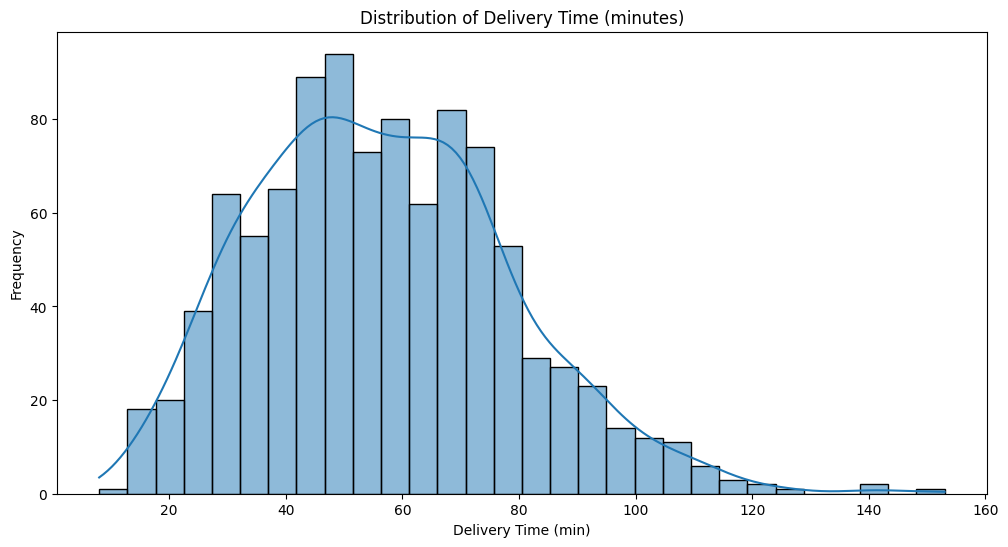

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.show()

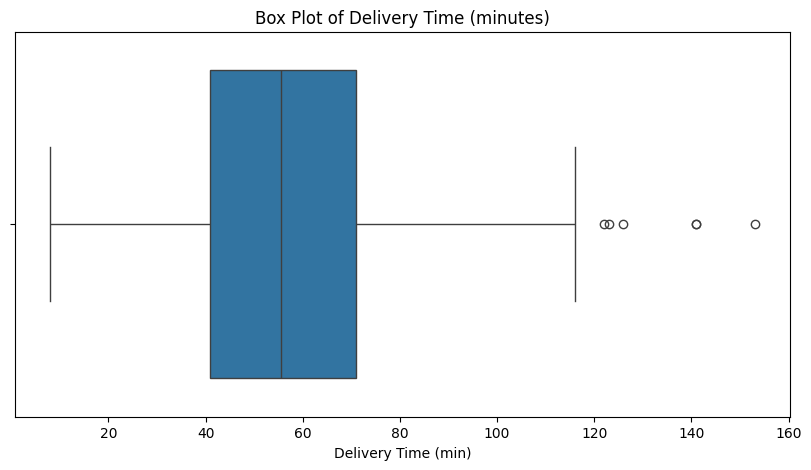

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.show()

<Axes: xlabel='Distance_km', ylabel='Delivery_Time_min'>

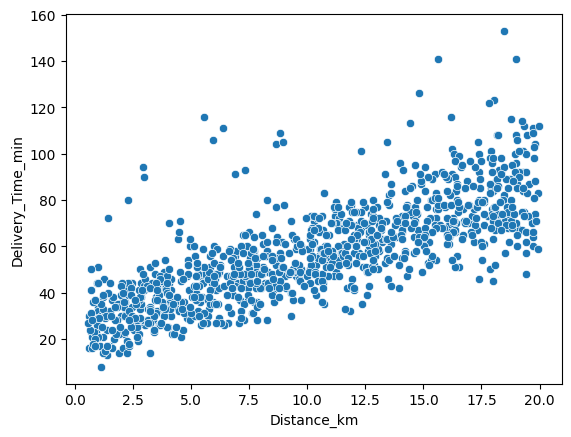

In [ ]:
sns.scatterplot(data = df,x = "Distance_km", y = "Delivery_Time_min")

### Relationship of `Delivery_Time_min` with other Numerical Features

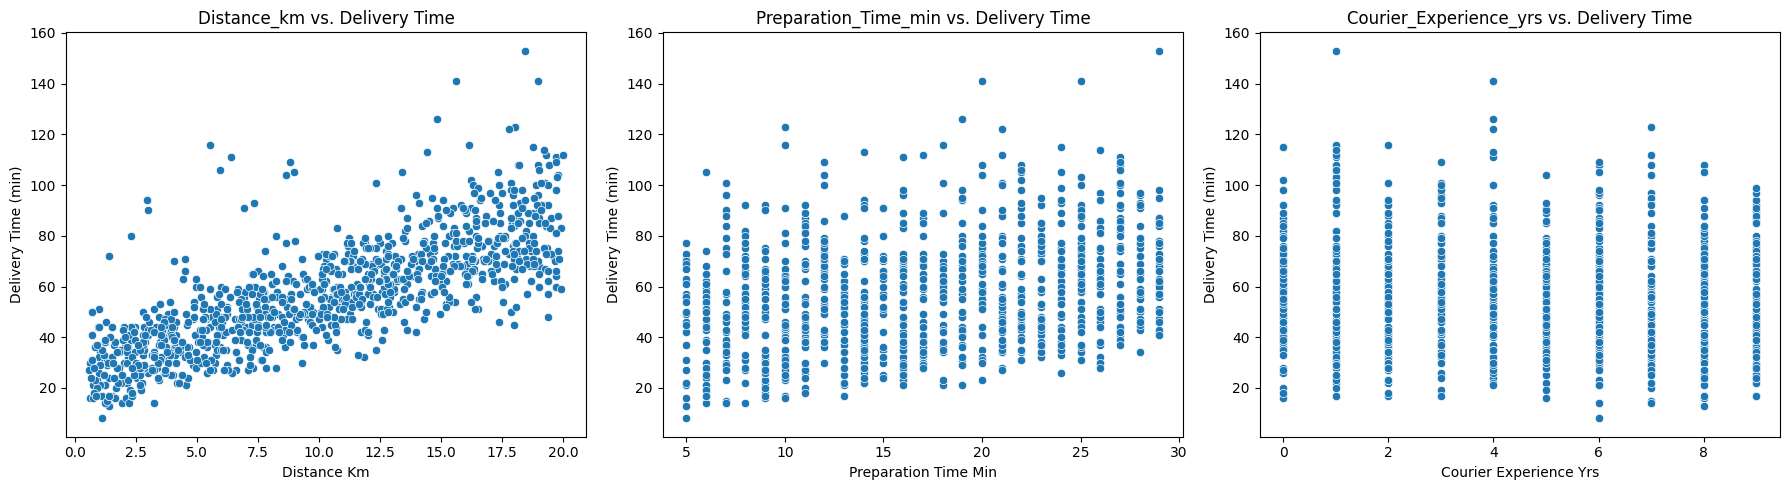

In [ ]:
numerical_cols_for_prediction = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

plt.figure(figsize=(18, 5))
for i, col in enumerate(numerical_cols_for_prediction):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=df, x=col, y='Delivery_Time_min')
    plt.title(f'{col} vs. Delivery Time')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.show()

### Relationship of `Delivery_Time_min` with Categorical Features

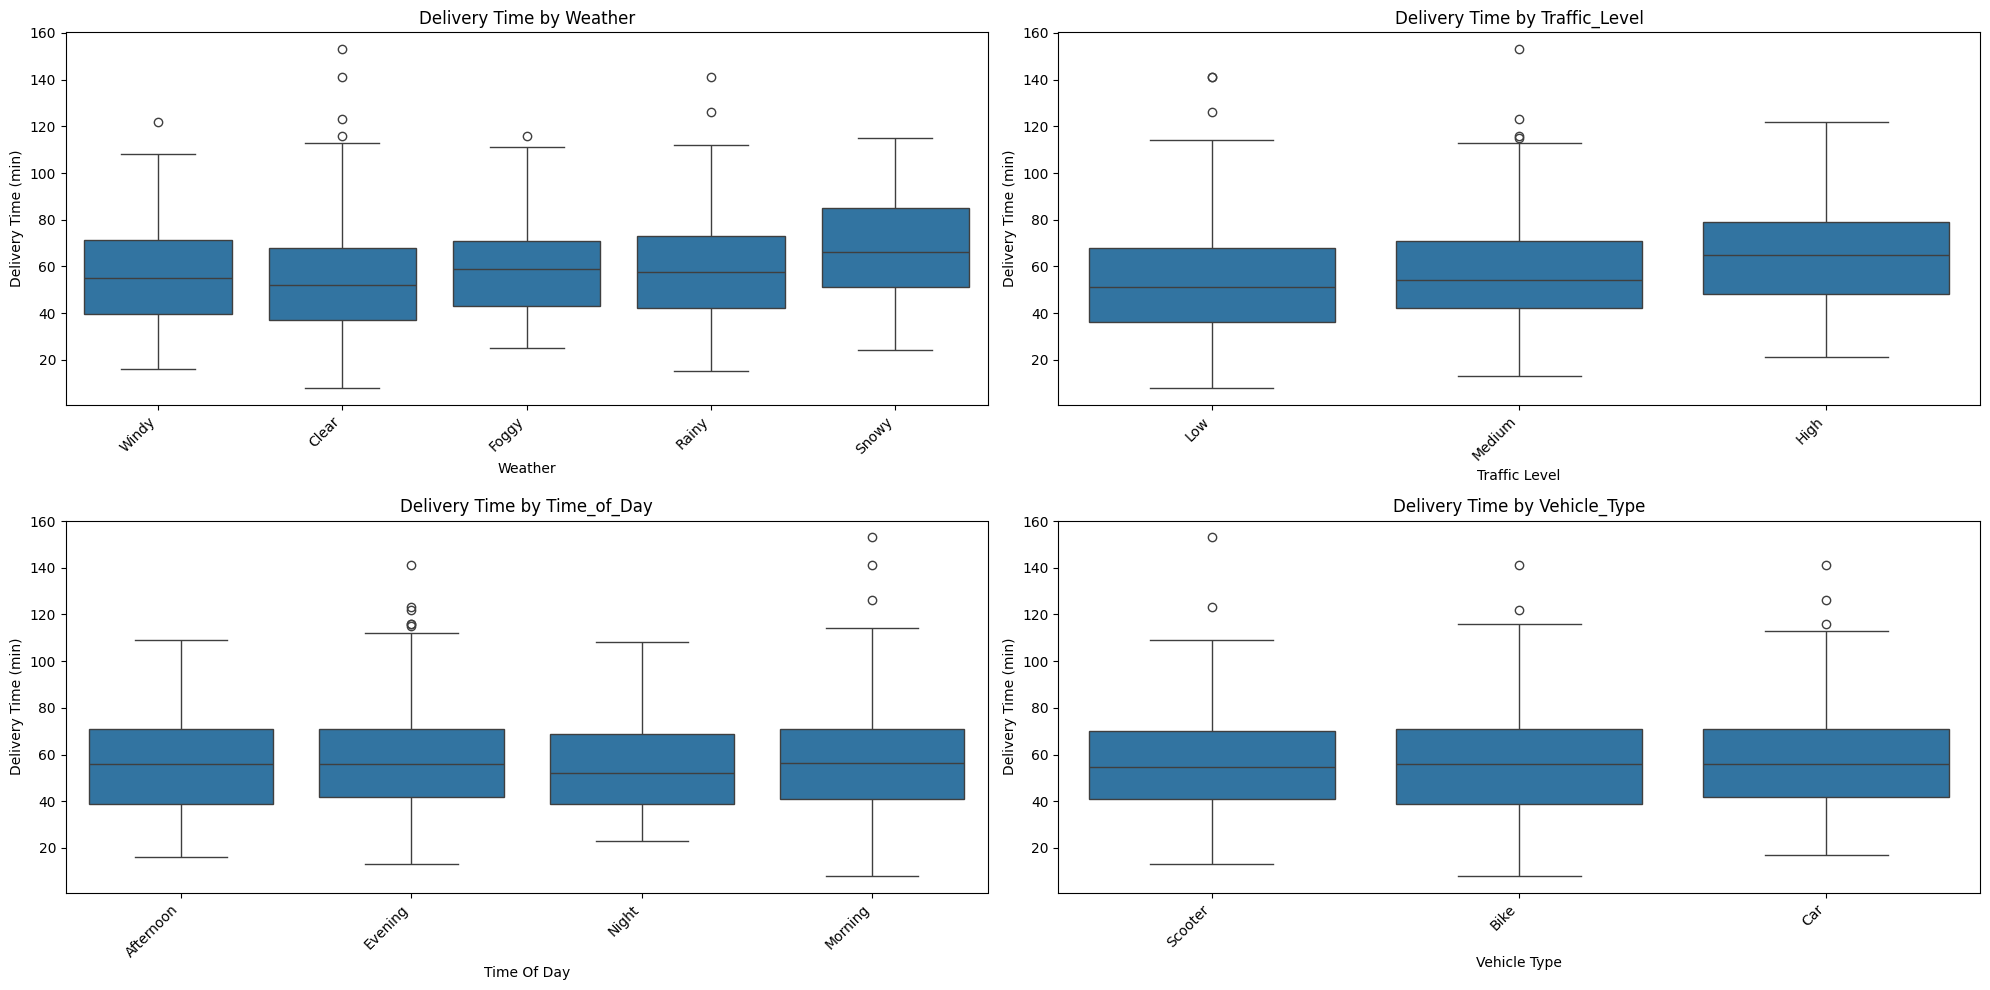

In [ ]:
categorical_cols_for_prediction = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(20, 10))
for i, col in enumerate(categorical_cols_for_prediction):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x=col, y='Delivery_Time_min')
    plt.title(f'Delivery Time by {col}')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#1000
#800 rows
# 200 rows

from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(['Delivery_Time_min','Order_ID'],axis= 1)
y = df['Delivery_Time_min']

In [ ]:
X

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0
1,16.42,Clear,Medium,Evening,Bike,20,2.0
2,9.52,Foggy,Low,Night,Scooter,28,1.0
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0
4,19.03,Clear,Low,Morning,Bike,16,5.0
...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0
996,16.28,Rainy,Low,Morning,Scooter,8,9.0
997,15.62,Snowy,High,Evening,Scooter,26,2.0
998,14.17,Clear,Low,Afternoon,Bike,8,0.0


In [ ]:
# Columns to be one-hot encoded
categorical_cols_to_encode = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Columns to keep as they are (numerical features)
numerical_cols_to_keep = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

# Create a copy of X to avoid modifying the original DataFrame directly
X_processed = X.copy()

# Apply one-hot encoding to the specified categorical columns
X_encoded_categorical = pd.get_dummies(X_processed[categorical_cols_to_encode], dummy_na=False)

# Combine the one-hot encoded categorical columns with the numerical columns
X_encoded = pd.concat([X_processed[numerical_cols_to_keep], X_encoded_categorical], axis=1)

X_encoded.head()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,12,1.0,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True
1,16.42,20,2.0,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False
2,9.52,28,1.0,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True
3,7.44,5,1.0,False,False,True,False,False,False,False,True,True,False,False,False,False,False,True
4,19.03,16,5.0,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False


In [ ]:
X_encoded = X_encoded.astype(int)

In [ ]:
X_encoded

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7,12,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,16,20,2,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,9,28,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,7,5,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,19,16,5,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8,13,3,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0
996,16,8,9,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
997,15,26,2,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
998,14,8,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()